# 1st Workflow: HUA Workflow (Housing Unit Analysis)

In [1]:
# import os, winreg
# with winreg.OpenKey(winreg.HKEY_CURRENT_USER, "Environment") as regkey:
#     os.environ["CENSUS_API_KEY"] = winreg.QueryValueEx(regkey, "CENSUS_API_KEY")[0]
# print("CENSUS_API_KEY loaded:", "CENSUS_API_KEY" in os.environ)


## Loading the Community

In [2]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

In [3]:
# select a community from this list
# if your community is not in this list, add it to the file ncoda_00g_community_options.py
list_community_options(communities_dictionary)

['Lumberton, NC: IN-CORE Building inventory for Robeson County, NC',
 'Galveston, TX: IN-CORE Building inventory for Galveston County, TX',
 'Galveston, TX: NSI Building inventory for Galveston County, TX',
 'Galveston, TX: IN-CORE Building inventory for Galveston Island, TX',
 'Mayfield, KY: NSI Building inventory for Graves County, KY',
 'Beaumont, TX: NSI Building inventory for Jefferson County, TX',
 'Beaumont, TX: Safayet Building inventory for Jefferson County, TX',
 'Pentwater, MI: NSI Building inventory for Oceana County, MI',
 'Seaside, OR: NSI Building inventory for Clatsop County, OR',
 'Lane County, OR: NSI Building inventory for Lane County, OR',
 'Benton County, OR: NSI Building inventory for Benton County, OR',
 'Grays Harbor, WA: NSI Building inventory for Grays Harbor County, WA',
 'Southeast Texas Urban Integrated Field Lab: NSI Building inventory for Southeast Texas',
 'Southeast Texas Urban Integrated Field Lab (12 neighbor counties): NSI Building inventory for Sout

In [4]:
community_id_by_name = 'Grays Harbor, WA: NSI Building inventory for Grays Harbor County, WA'

In [5]:
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)
communities = {community_id : communities_dictionary[community_id]}

Selected community ID: GraysHarbor_WA_NSI
Grays Harbor, WA is in WASHINGTON
Focal place: Aberdeen
Grays Harbor, WA is in Grays Harbor County, WA with FIPS code 53027
Use IN-CORE: False


## Setiing up the Environment

In [6]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs

In [7]:
# %pip install folium

In [8]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [9]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Fri Aug 14 21:38:39 2026 UTC

                OS : Windows (11 10.0.22621 SP0 Multiprocessor Free)
            CPU(s) : 4
           Machine : AMD64
      Architecture : 64bit
               RAM : 15.7 GiB
       Environment : Jupyter

  Python 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC
  v.1938 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.7.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.11.2

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [10]:
# Check working directory - good practice for relative path access
os.getcwd()

'c:\\Users\\USER\\icd-disability'

## Run Housing Unit Allocation
### The following code will produce the following outputs:
1. Housing Unit Inventory
2. Address Point Invento y
3. Housing Unit Allocation

In [11]:
basevintage_options = ['2020']

In [12]:
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [13]:
hua_hui_gdf_dict = {}
base_seed = 9876
iterations = 2
# iterate through basevintage options to run Monte Carlo Simulation
for basevintage in basevintage_options:
    hua_hui_gdf_dict[basevintage] = {}
    for i in range(iterations):
        seed_i = base_seed + i
        print(f"Running iteration {i+1} of {iterations} for basevintage {basevintage} with seed {seed_i}")
        workflow = process_community_workflow(
                    communities,
                    seed = seed_i,
                    version = '2.1.0',
                    version_text = 'v2-1-0',
                    basevintage = basevintage,
                    outputfolder ="OutputData_HUA",
                    outputfolders = {},
                    savefiles = True)
        hua_hui_gdf_dict[basevintage][seed_i] = workflow.process_communities()

Running iteration 1 of 2 for basevintage 2020 with seed 9876
Generating Housing Unit Inventory v2.0.0 data for Grays Harbor, WA
Grays Harbor County, WA : county FIPS Code 53027
File already exists, skipping: OutputData_HUA/GraysHarbor_WA_NSI/../hui_v2-1-0_GraysHarbor_WA_NSI_2020_rs9876.csv
Checking output for huid
Checking output for blockid
Checking output for bgid
Checking output for tractid
Checking output for FIPScounty
Checking output for numprec
Checking output for ownershp
Checking output for race
Checking output for hispan
Checking output for family
Checking output for vacancy
Checking output for gqtype
Checking output for incomegroup
Checking output for hhinc
Checking output for randincome
Checking output for poverty
Checking huid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
Checking blockid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
    Length of blockid is correct
Checking bgid Data

In [14]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in this directory:")
print(os.listdir())

Current working directory:
c:\Users\USER\icd-disability

Files in this directory:
['.claude', '.devcontainer', '.git', '.gitattributes', '.github', '.gitignore', '.ipynb_checkpoints', '.virtual_documents', 'Admin', 'Archive', 'BETA_TEST_LOG.md', 'CITATION.cff', 'environment.yml', 'HUA_Disability_2010.ipynb', 'HUA_Disability_2020.ipynb', 'IN-CORE_HRRC_Banner.png', 'LICENSE', 'ncoda_07iv1_SimCenter_HUA.ipynb', 'ncoda_07jv4_HUA_NSI_Hayward.ipynb', 'ncoda_07jv5_HUA_NSI_Hayward.ipynb', 'ncoda_08av1_PyPDFcodebook.ipynb', 'OutputData', 'OutputData_HUA', 'OutputData_PREC', 'PROJECT_CONTEXT.md', 'pyncoda', 'pyproject.toml', 'Readings', 'README.md', 'requirements.txt', 'requirements_new.txt', 'SampleOutputData', 'temp.csv']


## Explore and Validate Housing Unit Allocation

### Look at population characteristics and compare to US Census

In [15]:
where = communities[community_id]['community_name']
print(where, focalplace, countyname, countyfips)

Grays Harbor, WA Aberdeen Grays Harbor County, WA 53027


### 2020 - Total Population by Households by Tenure Status (Seed: 9876)

In [16]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'][9876], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","41,074 (82.7%)","15,542 (69.6%)","56,616 (78.7%)"
"2 Black alone, Not Hispanic",179 (0.4%),279 (1.3%),458 (0.6%)
"3 American Indian and Alaska Native alone, Not Hispanic","1,855 (3.7%)","1,386 (6.2%)","3,241 (4.5%)"
"4 Asian alone, Not Hispanic",710 (1.4%),249 (1.1%),959 (1.3%)
"5 Other Race, Not Hispanic","2,759 (5.6%)","1,539 (6.9%)","4,298 (6.0%)"
"6 Any Race, Hispanic","3,067 (6.2%)","3,324 (14.9%)","6,391 (8.9%)"
Total,"49,644 (100.0%)","22,319 (100.0%)","71,963 (100.0%)"


### 2020 - Total Population by Households by Tenure Status (Seed: 9877)

In [17]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'][9877], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","41,074 (82.7%)","15,542 (69.6%)","56,616 (78.7%)"
"2 Black alone, Not Hispanic",179 (0.4%),279 (1.3%),458 (0.6%)
"3 American Indian and Alaska Native alone, Not Hispanic","1,855 (3.7%)","1,386 (6.2%)","3,241 (4.5%)"
"4 Asian alone, Not Hispanic",710 (1.4%),249 (1.1%),959 (1.3%)
"5 Other Race, Not Hispanic","2,759 (5.6%)","1,539 (6.9%)","4,298 (6.0%)"
"6 Any Race, Hispanic","3,067 (6.2%)","3,324 (14.9%)","6,391 (8.9%)"
Total,"49,644 (100.0%)","22,319 (100.0%)","71,963 (100.0%)"


### 2020 - Total Population by Households by Hispanic (Seed: 9876)

In [18]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'][9876], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","56,616 (86.3%)",nan (nan%),"56,616 (78.7%)"
"2 Black alone, Not Hispanic",458 (0.7%),nan (nan%),458 (0.6%)
"3 American Indian and Alaska Native alone, Not Hispanic","3,241 (4.9%)",nan (nan%),"3,241 (4.5%)"
"4 Asian alone, Not Hispanic",959 (1.5%),nan (nan%),959 (1.3%)
"5 Other Race, Not Hispanic","4,298 (6.6%)",nan (nan%),"4,298 (6.0%)"
"6 Any Race, Hispanic",nan (nan%),"6,391 (100.0%)","6,391 (8.9%)"
Total,"65,572 (100.0%)","6,391 (100.0%)","71,963 (100.0%)"


In [19]:
### 2020 - Total Population by Households by Hispanic (Seed: 9877)

In [20]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'][9877], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","56,616 (86.3%)",nan (nan%),"56,616 (78.7%)"
"2 Black alone, Not Hispanic",458 (0.7%),nan (nan%),458 (0.6%)
"3 American Indian and Alaska Native alone, Not Hispanic","3,241 (4.9%)",nan (nan%),"3,241 (4.5%)"
"4 Asian alone, Not Hispanic",959 (1.5%),nan (nan%),959 (1.3%)
"5 Other Race, Not Hispanic","4,298 (6.6%)",nan (nan%),"4,298 (6.0%)"
"6 Any Race, Hispanic",nan (nan%),"6,391 (100.0%)","6,391 (8.9%)"
Total,"65,572 (100.0%)","6,391 (100.0%)","71,963 (100.0%)"


### 2020 - Median Household Income by Tanure (Seed: 9876)

In [21]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2020'][9876], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2020 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$62,927","$53,612","$59,994"
"2 Black alone, Not Hispanic","$59,308","$66,486","$63,201"
"3 American Indian and Alaska Native alone, Not Hispanic","$51,850","$47,331","$49,118"
"4 Asian alone, Not Hispanic","$72,256","$69,994","$71,622"
"5 Other Race, Not Hispanic","$63,630","$53,447","$59,676"
"6 Any Race, Hispanic","$56,034","$49,352","$53,001"
Total,"$62,504","$53,184","$59,340"


### 2020 - Median Household Income by Tanure (Seed: 9877)

In [22]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2020'][9877], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2020 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$63,511","$52,126","$59,904"
"2 Black alone, Not Hispanic","$72,491","$70,171","$70,334"
"3 American Indian and Alaska Native alone, Not Hispanic","$55,383","$42,999","$48,889"
"4 Asian alone, Not Hispanic","$71,314","$70,291","$71,127"
"5 Other Race, Not Hispanic","$63,071","$53,432","$58,830"
"6 Any Race, Hispanic","$56,876","$49,439","$53,081"
Total,"$63,043","$51,936","$59,206"


### Validation

In [23]:
print("Total Population by Race and Ethnicity:")
print(f"https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=DECENNIALDHC2020.P5")

print("Median Income by Race and Ethnicity:")
print(f"All Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2022.B19013")
print(f"Black Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2022.B19013B")
print(f"White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2022.B19013H")
print(f"Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2022.B19013I")

Total Population by Race and Ethnicity:
https://data.census.gov/cedsci/table?g=050XX00US53027&tid=DECENNIALDHC2020.P5
Median Income by Race and Ethnicity:
All Households: https://data.census.gov/cedsci/table?g=050XX00US53027&tid=ACSDT5Y2022.B19013
Black Households: https://data.census.gov/cedsci/table?g=050XX00US53027&tid=ACSDT5Y2022.B19013B
White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US53027&tid=ACSDT5Y2022.B19013H
Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US53027&tid=ACSDT5Y2022.B19013I


### Explore Maps

In [24]:
focalplace

'Aberdeen'

In [25]:
hua_hui_race_gdf_dict = {}
county_hua_gdf_dict = {}
focal_place_hua_gdf_dict = {}

In [26]:
# Import all three modules to make their functions available
from pyncoda import ncoda_04c_poptableresults
from pyncoda import ncoda_04a_Figures
from pyncoda import ncoda_04b_foliummaps

# Import everything from these modules (makes all functions directly accessible)
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_04a_Figures import *
from pyncoda.ncoda_04b_foliummaps import *

print("✓ All three modules imported successfully")


✓ All three modules imported successfully


[-123.851977, -123.743091] [46.951781, 47.001003]


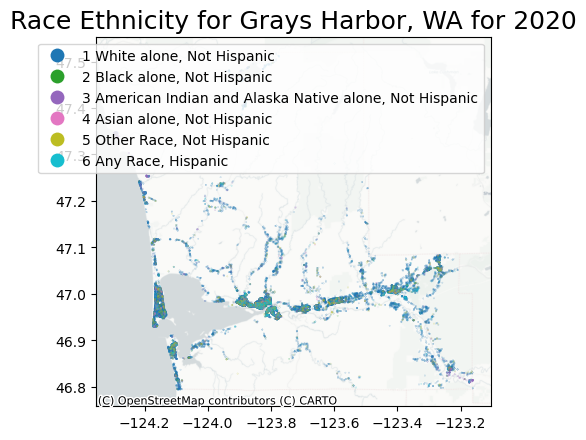

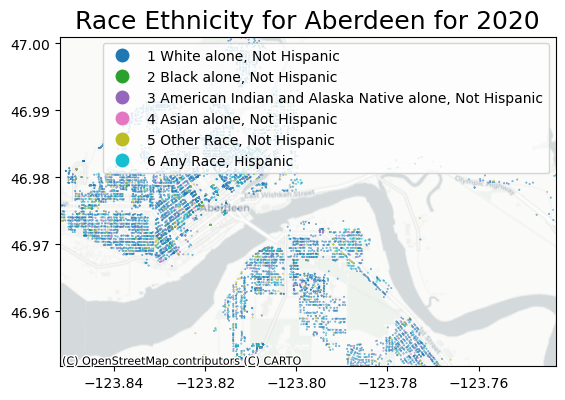

In [27]:

seed_i = 9876

for year in ['2020']:
    # add race ethnicity to data frame for better map legends
    hua_hui_race_gdf_dict[year] = PopResultsTable.add_race_ethnicity_to_pop_df(hua_hui_gdf_dict[year][seed_i])

    #mapname = 'hhincdotmap'
    mapname = f'hhracedotmap_{year}'
    # Map column
    #map_var = 'Household Income Group'
    map_var = 'Race Ethnicity'
    place = focalplace

    yr = str(year)[2:4]
    condition1 = "(hua_hui_race_gdf_dict[year].race >= 1)"
    condition2 = f"(hua_hui_race_gdf_dict[year].placeNAME{yr} == '{place}')"
    conditions = f"{condition1} & {condition2}"

    county_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(condition1)].copy(deep=True)
    county_hua_gdf_dict[year] = county_hua_gdf_dict[year].to_crs(epsg=4326)
    focal_place_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(conditions)].copy(deep=True)
    focal_place_hua_gdf_dict[year] = focal_place_hua_gdf_dict[year].to_crs(epsg=4326)

    bldg_inv_id = communities[community_id]['building_inventory']['id']
    outputfolder = 'OutputData_HUA'
    community = communities[community_id]['community_name']

    county_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                            mapname=mapname,
                            map_var=map_var,
                            bldg_inv_id=bldg_inv_id,
                            community=community_id,
                            place = community,
                            year = year,
                            outputfolder=outputfolder,
                            condition_id = "1",
                            basemap_source = cx.providers.CartoDB.Positron)
    
    # get xlim and ylim for focal place
    xlim = [focal_place_hua_gdf_dict[year].total_bounds[0], focal_place_hua_gdf_dict[year].total_bounds[2]]
    ylim = [focal_place_hua_gdf_dict[year].total_bounds[1], focal_place_hua_gdf_dict[year].total_bounds[3]]
    print(xlim, ylim)

    focal_place_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                        mapname=mapname,
                        map_var=map_var,
                        bldg_inv_id=bldg_inv_id,
                        community=community_id,
                        place = focalplace,
                        year = year,
                        outputfolder=outputfolder,
                        condition_id = "2",
                        basemap_source = cx.providers.CartoDB.Positron,
                        xlim = xlim,
                        ylim = ylim,
                        focal_gdf = focal_place_hua_gdf_dict[year])

### Spatial Analysis

In [28]:
# Install individually
# !pip install esda --break-system-packages
# !pip install libpysal --break-system-packages
# !pip install splot --break-system-packages
# !pip install spreg --break-system-packages

In [29]:
# convert county name to string with _ instead of spaces
filename = "Grays_Harbor_County_WA_NSI"

# 2nd Workflow: PREC Workflow (Person Records with Disability)

In [30]:
# ==============================================================
# Step 1: Setup — imports and community configuration
# ==============================================================

%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
from IPython.display import display

from pyncoda.ncoda_00g_community_options import *
from pyncoda.CommunitySourceData.api_census_gov.acg_01a_BaseInventory import BaseInventory
from pyncoda.CommunitySourceData.api_census_gov.acg_00f_preci_block2020 import sexbyage_P12_2020_varstem_roots

# --- Community Setup ---
# NOTE: this workflow selects its own community, independently of the selection
# made for Workflow 1 near the top of the notebook. Running this cell reassigns
# community_id, countyname and state_county for the rest of the session.
# Both selections must name the same community, otherwise the person records
# are built for a different county than the housing unit allocation - with no
# warning, since each half is internally consistent.
community_id_by_name = 'Grays Harbor, WA: NSI Building inventory for Grays Harbor County, WA'
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)

state_county      = countyfips
state_county_name = countyname
seed              = 9876
basevintage       = '2020'

# --- Output folders ---
prec_outputfolder = "OutputData_PREC"
prec_base = f"{prec_outputfolder}/{community_id}"

prec_outputfolders = {
    'top'                    : prec_base,
    'logfiles'               : f"{prec_base}/00_logfiles",
    'CommunitySourceData'    : f"{prec_base}/01_CommunitySourceData",
    'TidyCommunitySourceData': f"{prec_base}/02_TidyCommunitySourceData",
    'BaseInventory'          : f"{prec_base}/03_BaseInventory",
    'RandomMerge'            : f"{prec_base}/04_RandomMerge",
}
for folder in prec_outputfolders.values():
    os.makedirs(folder, exist_ok=True)

print(f"Community    : {community_id}")
print(f"State/County : {state_county} — {state_county_name}")
print(f"Seed         : {seed}")
print(f"Base vintage : {basevintage}")
print("Folders ready ✓")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Selected community ID: GraysHarbor_WA_NSI
Grays Harbor, WA is in WASHINGTON
Focal place: Aberdeen
Grays Harbor, WA is in Grays Harbor County, WA with FIPS code 53027
Use IN-CORE: False
Community    : GraysHarbor_WA_NSI
State/County : 53027 — Grays Harbor County, WA
Seed         : 9876
Base vintage : 2020
Folders ready ✓


In [31]:
# ==============================================================
# 2020 DHC support
#
# This cell used to monkey-patch BaseInventory.obtain_census_api with a local
# copy that added timeout + retry. That copy predated API key support, the
# non-JSON guard and the atomic cache write, so installing it silently undid
# all three and every request in this workflow failed. The retry logic now
# lives in the library function itself, so no patch is needed for it.
#
# What IS still needed are the two 2020 DHC patches below. They exist on this
# branch but were never imported anywhere, so the 2020 code paths they fix
# were never actually active - which is why Step 5 (PCT12) failed while the
# earlier steps, which use hand written dictionaries, appeared to work.
#
#   patch_obtain_api_metadata_for_2020
#       discovers variables as 'PCT12_001N' (2010 used 'PCT12001')
#   patch_get_data_for_2020
#       builds 2020 API names by concatenating varstem + varroot, and fixes
#       the rename loop. It calls BaseInventory.obtain_census_api, so API key,
#       retry and cache behaviour are all preserved.
# ==============================================================
from pyncoda.CommunitySourceData.api_census_gov.acg_00a_createAPI_datastructure import (
    createAPI_datastructure,
)
from pyncoda.CommunitySourceData.api_census_gov.acg_00a_createAPI_datastructure_2020_patch import (
    patch_obtain_api_metadata_for_2020,
    patch_get_data_for_2020,
)

patch_obtain_api_metadata_for_2020()
patch_get_data_for_2020()


[OK] createAPI_datastructure.obtain_api_metadata patched for 2020 DHC support
[OK] BaseInventory.get_data_based_on_varstems_and_roots patched for 2020 DHC support


In [32]:
# ==============================================================
# Step 2: Create block-level person records from P12 (Sex by Age)
# ==============================================================
block_df = {}

block_df['preci'] = BaseInventory.get_apidata(
    state_county  = state_county,
    geo_level     = 'block',
    vintage       = basevintage,
    mutually_exclusive_varstems_roots_dictionaries = [sexbyage_P12_2020_varstem_roots],
    outputfolders = prec_outputfolders,
    outputfile    = 'CorePREC'
)

print(f"\nStep 2 complete: Block-level person records created.")
print(f"Shape   : {block_df['preci'].shape}")
print(f"Columns : {list(block_df['preci'].columns)}")
display(block_df['preci'].head(3))

File OutputData_PREC/GraysHarbor_WA_NSI/03_BaseInventory/CorePREC_53027_2020.csv Already exists - Skipping API Call.

Step 2 complete: Block-level person records created.
Shape   : (75636, 9)
Columns : ['precid', 'Block2020', 'Block2020str', 'sex', 'minageyrs', 'maxageyrs', 'race', 'hispan', 'prec_counter']


,precid,Block2020,Block2020str,sex,minageyrs,maxageyrs,race,hispan,prec_counter
0,B530270002011000P0001,530270002011000,B530270002011000,1,35,39,1,0,1
1,B530270002011000P0002,530270002011000,B530270002011000,1,65,66,1,0,2
2,B530270002011000P0003,530270002011000,B530270002011000,1,65,66,1,0,3


In [33]:
# ==============================================================
# Step 3: Add Hispanic ethnicity via graft method
# ==============================================================
from pyncoda.CommunitySourceData.api_census_gov.acg_00f_preci_block2020 import (
    sexbyage_P12HAI_2020_varstem_roots,
    hispan_byrace_P5_2020_varstem_roots
)

block_df['precihispan'] = BaseInventory.graft_on_new_char(
    base_inventory        = block_df['preci'],
    state_county          = state_county,
    new_char              = 'hispan',
    new_char_dictionaries = [
        sexbyage_P12HAI_2020_varstem_roots,
        hispan_byrace_P5_2020_varstem_roots
    ],
    basevintage   = '2020',          # ← THE FIX
    outputfile    = 'preci',
    outputfolders = prec_outputfolders
)

print(f"\nStep 3 complete: Hispanic ethnicity added.")
print(f"Shape   : {block_df['precihispan'].shape}")
print(f"Columns : {list(block_df['precihispan'].columns)}")
print(f"\nhispan value counts:")
print(block_df['precihispan']['hispan'].value_counts().sort_index())
display(block_df['precihispan'].head(3))

File OutputData_PREC/GraysHarbor_WA_NSI/03_BaseInventory/preci_hispan_53027_2020.csv Already exists with new variable grafted - Skipping API Call.

Step 3 complete: Hispanic ethnicity added.
Shape   : (75636, 24)
Columns : ['precid', 'Block2020', 'Block2020str', 'sex', 'minageyrs', 'maxageyrs', 'race', 'hispan', 'prec_counter', 'hispan_flag', 'hispan_flagset', 'totalprob_hispan', 'hispanbyP12HAI', 'preccount_hispanbyP12HAI', 'sumby_hispanbyP12HAI', 'prob_hispanbyP12HAI', 'hispanbyP5', 'preccount_hispanbyP5', 'sumby_hispanbyP5', 'prob_hispanbyP5', 'hispanbyP12HAI_counter', 'hispanbyP5_counter', 'preccount_hispanbyP12HAIupdated', 'preccount_hispanbyP5updated']

hispan value counts:
hispan
0.0    67791
1.0     7845
Name: count, dtype: int64


,precid,Block2020,Block2020str,sex,minageyrs,maxageyrs,race,hispan,prec_counter,hispan_flag,...,sumby_hispanbyP12HAI,prob_hispanbyP12HAI,hispanbyP5,preccount_hispanbyP5,sumby_hispanbyP5,prob_hispanbyP5,hispanbyP12HAI_counter,hispanbyP5_counter,preccount_hispanbyP12HAIupdated,preccount_hispanbyP5updated
0,B530270002011000P0001,530270002011000,B530270002011000,1.0,35.0,39.0,1.0,0.0,1.0,hispan set to 0 by core hui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B530270002011000P0002,530270002011000,B530270002011000,1.0,65.0,66.0,1.0,0.0,2.0,hispan set to 0 by core hui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B530270002011000P0003,530270002011000,B530270002011000,1.0,65.0,66.0,1.0,0.0,3.0,hispan set to 0 by core hui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# ==============================================================
# Step 4: Add random age to block and tract records
# ==============================================================

from pyncoda.CommunitySourceData.api_census_gov.acg_02c_agefunctions import (
    add_randage,
    add_P12age_groups
)

# --- Step 4a: Add random age to block-level person records ---
block_df['precihispan'] = add_randage(
    block_df['precihispan'],
    seed    = seed,
    varname = 'randageP12'
)
block_df['precihispan'] = add_P12age_groups(
    block_df['precihispan'],
    varname = 'randageP12'
)

print(f"Step 4a complete: Random age added to block records.")
print(f"Shape      : {block_df['precihispan'].shape}")
print(f"\nrandageP12 sample stats:")
print(block_df['precihispan']['randageP12'].describe())
print(f"\nagegroupP12 value counts:")
print(block_df['precihispan']['agegroupP12'].value_counts().sort_index())

Step 4a complete: Random age added to block records.
Shape      : (75636, 26)

randageP12 sample stats:
count    75636.000000
mean        42.616175
std         24.106623
min          0.000000
25%         22.000000
50%         43.000000
75%         62.000000
max        109.000000
Name: randageP12, dtype: float64

agegroupP12 value counts:
agegroupP12
1.0     3741
2.0     4139
3.0     4567
4.0     2659
5.0     1572
6.0      740
7.0      729
8.0     2103
9.0     3971
10.0    4628
11.0    4687
12.0    4457
13.0    4303
14.0    4679
15.0    5494
16.0    2417
17.0    3705
18.0    2576
19.0    3482
20.0    4894
21.0    2939
22.0    1718
23.0    1436
Name: count, dtype: int64


In [35]:
# ==============================================================
# Step 5: Fetch tract-level PCT12 data and add random age
# ==============================================================

tract_df = {}
group = 'PCT12'

# --- Step 5a: Fetch PCT12 variable structure (uses patched 2020-aware function) ---
sexbyage_PCT12_varstem_roots = createAPI_datastructure.obtain_api_metadata(
    vintage      = '2020',
    dataset_name = 'dec/dhc',
    group        = group,
    outputfolder = prec_outputfolder
)

# --- Step 5b: Pull tract-level PCT12 data ---
tract_df['PCT12'] = BaseInventory.get_apidata(
    state_county  = state_county,
    geo_level     = 'tract',
    vintage       = '2020',
    mutually_exclusive_varstems_roots_dictionaries = [sexbyage_PCT12_varstem_roots],
    outputfolders = prec_outputfolders,
    outputfile    = group
)

# --- Step 5c: Add random age to tract records ---
tract_df['PCT12'] = add_randage(
    tract_df['PCT12'],
    seed    = seed,
    varname = 'randagePCT12'
)
tract_df['PCT12'] = add_P12age_groups(
    tract_df['PCT12'],
    varname = 'randagePCT12'
)

print(f"Step 5 complete: Tract-level PCT12 data fetched and age added.")
print(f"Shape   : {tract_df['PCT12'].shape}")
print(f"Columns : {list(tract_df['PCT12'].columns)}")
print(f"\nrandagePCT12 sample stats:")
print(tract_df['PCT12']['randagePCT12'].describe())
display(tract_df['PCT12'].head(3))

Obtaining data structure for PCT12
Check weblink for variable list: https://api.census.gov/data/2020/dec/dhc/groups/PCT12.html.
Assume reached the end of variable list with PCT12_210N
dict_keys(['metadata', 'PCT12'])
Remove _001N from dictionary.
Remove _002N from dictionary.
Remove _106N from dictionary.
Data structure has 206 variables.
Data structure for API call will have too many variables.
Census API limits data to 50 variables - including GEOID and geovars.
Need to split up varstem into parts.
Max variables for API call reached. Starting new varstem part 2
Max variables for API call reached. Starting new varstem part 3
Max variables for API call reached. Starting new varstem part 4
Max variables for API call reached. Starting new varstem part 5
{'top': 'OutputData_PREC/GraysHarbor_WA_NSI', 'logfiles': 'OutputData_PREC/GraysHarbor_WA_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/GraysHarbor_WA_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/Gr

,index,GEO_ID,state,county,tract,sex,minageyrs,maxageyrs,prec_counter,randagePCT12,agegroupP12
0,11,1400000US53027000201,53,027,000201,1,0,0,1,0.0,1.0
1,11,1400000US53027000201,53,027,000201,1,0,0,2,0.0,1.0
2,11,1400000US53027000201,53,027,000201,1,0,0,3,0.0,1.0


In [36]:
# ==============================================================
# Step 6a: Random merge tract age onto block person records
# ==============================================================

from pyncoda.CommunitySourceData.api_census_gov.acg_02a_add_categorical_char import add_new_char_by_random_merge_2dfs

add_age = add_new_char_by_random_merge_2dfs(
    dfs = {
        'primary'  : {'data'       : block_df['precihispan'],
                      'primarykey' : 'precid',
                      'geolevel'   : 'Block',
                      'geovintage' : '2020',
                      'notes'      : 'Block age, sex, race, ethnicity data.'},
        'secondary': {'data'       : tract_df['PCT12'],
                      'primarykey' : 'uniqueidPCT12',
                      'geolevel'   : 'Tract',
                      'geovintage' : '2020',
                      'notes'      : 'Tract single-year age, sex data.'}
    },
    seed              = seed,
    common_group_vars = ['agegroupP12'],
    new_char          = 'randagePCT12',
    geolevel          = 'Tract',
    geovintage        = '2020',
    by_groups         = {'All': {'by_variables': ['sex']}},
    fillna_value      = -999,
    state_county      = state_county,
    outputfile        = 'preci_randomage',
    outputfolder      = prec_outputfolders['RandomMerge']
)

rounds = {'options': {
    'option1': {
        'notes'            : 'By original common group vars and by groups variables.',
        'common_group_vars': add_age.common_group_vars,
        'by_groups'        : add_age.by_groups
    }},
    'geo_levels': ['Tract']
}

prec_age_df = add_age.run_random_merge_2dfs(rounds)

# Sanity check
primary_df = prec_age_df['primary']
print(f"\nStep 6 complete: Tract age merged onto block person records.")
print(f"Shape   : {primary_df.shape}")
print(f"Columns : {list(primary_df.columns)}")
print(f"\nrandagePCT12 assignment flags:")
print(primary_df['randagePCT12_flagsetrm'].value_counts().sort_index())
print(f"\nrandagePCT12 stats:")
print(primary_df['randagePCT12'].describe())
display(primary_df.head(3))

Round 1
Performing random merge at geography level: Tract
By original common group vars and by groups variables.
Running random merge by ['Tract2020', 'sex', 'agegroupP12']
    Setting up  primary data with primary key and flags
Geolevels available []
Geolvarids available ['Block2020']
Adding Tract2020 expected length 11
Dataframe has Block 2020 for new geovar Tract2020
Confirming Tract2020 has expected length.
Checking primary key name precid
Primary key variable precid is unique.
Primary key precid has no missing values
Initializing primary flag set variable for randagePCT12
New flag: randagePCT12_flagsetrm
['precid', 'Tract2020', 'Block2020', 'Block2020str', 'sex', 'minageyrs', 'maxageyrs', 'race', 'hispan', 'prec_counter', 'hispan_flag', 'hispan_flagset', 'totalprob_hispan', 'hispanbyP12HAI', 'preccount_hispanbyP12HAI', 'sumby_hispanbyP12HAI', 'prob_hispanbyP12HAI', 'hispanbyP5', 'preccount_hispanbyP5', 'sumby_hispanbyP5', 'prob_hispanbyP5', 'hispanbyP12HAI_counter', 'hispanbyP5_co

c:\Users\USER\icd-disability\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:788: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = self.round+.5


After update observations geovar flag set 1 = 75636
    Check random merge results for primary data.
Check by geovar flag randagePCT12_Tract2020_flagsetrm
Observations flag not equal to 0 75636
Input and output data have the same length 75636
Outputdata has 75636 Observations with predicted randagePCT12
Percent left to predict:  0.00
    Overwrite input data with update output data.
Flag vars available ['randagePCT12_flagsetrm', 'randagePCT12_Tract2020_flagsetrm']
Before update output_df observations flag set 1 = 0
Before update results observations flag set 1 = 75636
After update observations geovar flag set 1 = 75636
    Check random merge results for secondary data.
Check by geovar flag randagePCT12_Tract2020_flagsetrm
Observations flag not equal to 0 75636
Input and output data have the same length 75636
Outputdata has 75636 Observations with predicted randagePCT12
Percent left to predict:  0.00
    Overwrite input data with update output data.

++++++++++++++++++++++++++++++++++++

,precid,Tract2020,Block2020,Block2020str,sex,minageyrs,maxageyrs,race,hispan,prec_counter,...,prob_hispanbyP5,hispanbyP12HAI_counter,hispanbyP5_counter,preccount_hispanbyP12HAIupdated,preccount_hispanbyP5updated,randageP12,agegroupP12,randagePCT12,randagePCT12_flagsetrm,randagePCT12_Tract2020_flagsetrm
0,B530270002011000P0001,53027000201,530270002011000,B530270002011000,1.0,35.0,39.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,38.0,11.0,39.0,1,1.0
1,B530270002011000P0002,53027000201,530270002011000,B530270002011000,1.0,65.0,66.0,1.0,0.0,2.0,...,NaN,NaN,NaN,NaN,NaN,65.0,18.0,65.0,1,1.0
2,B530270002011000P0003,53027000201,530270002011000,B530270002011000,1.0,65.0,66.0,1.0,0.0,3.0,...,NaN,NaN,NaN,NaN,NaN,65.0,18.0,66.0,1,1.0


In [37]:
# Check vintage, dataset, and structure of all 7 disability tables (B18101–B18107)
from pyncoda.CommunitySourceData.api_census_gov.acg_00h_disability_ACS5yr2022 import (
    disability_B18101_varstem_roots_2022,
    disability_B18102_varstem_roots_2022,
    disability_B18103_varstem_roots_2022,
    disability_B18104_varstem_roots_2022,
    disability_B18105_varstem_roots_2022,
    disability_B18106_varstem_roots_2022,
    disability_B18107_varstem_roots_2022,
)

all_dicts = {
    'B18101 (overall disability)':       disability_B18101_varstem_roots_2022,
    'B18102 (hearing difficulty)':       disability_B18102_varstem_roots_2022,
    'B18103 (vision difficulty)':        disability_B18103_varstem_roots_2022,
    'B18104 (cognitive difficulty)':     disability_B18104_varstem_roots_2022,
    'B18105 (ambulatory difficulty)':    disability_B18105_varstem_roots_2022,
    'B18106 (self-care difficulty)':     disability_B18106_varstem_roots_2022,
    'B18107 (indep. living difficulty)': disability_B18107_varstem_roots_2022,
}

for name, d in all_dicts.items():
    md = d['metadata']
    var_count = len(d[md['group'] + '_'])   # e.g. d['B18101_']
    print(f"{name}")
    print(f"  vintage      : {md['vintage']}")
    print(f"  dataset_name : {md['dataset_name']}")
    print(f"  new_char     : {md['new_char']}")
    print(f"  char_vars    : {md['char_vars']}")
    print(f"  variables    : {var_count} variable codes")
    print()

B18101 (overall disability)
  vintage      : 2022
  dataset_name : acs/acs5
  new_char     : disability
  char_vars    : ['sex', 'agegroupB18101', 'disability']
  variables    : 24 variable codes

B18102 (hearing difficulty)
  vintage      : 2022
  dataset_name : acs/acs5
  new_char     : hearing_difficulty
  char_vars    : ['sex', 'agegroupB18101', 'hearing_difficulty']
  variables    : 24 variable codes

B18103 (vision difficulty)
  vintage      : 2022
  dataset_name : acs/acs5
  new_char     : vision_difficulty
  char_vars    : ['sex', 'agegroupB18101', 'vision_difficulty']
  variables    : 24 variable codes

B18104 (cognitive difficulty)
  vintage      : 2022
  dataset_name : acs/acs5
  new_char     : cognitive_difficulty
  char_vars    : ['sex', 'agegroupB18101', 'cognitive_difficulty']
  variables    : 20 variable codes

B18105 (ambulatory difficulty)
  vintage      : 2022
  dataset_name : acs/acs5
  new_char     : ambulatory_difficulty
  char_vars    : ['sex', 'agegroupB18101', 

In [38]:
# Ad hoc check of Census variable naming: B18101_004E vs B18101004E.
# Uses the community selected above and sends the API key, so that it tests
# what the workflow actually requests. Previously this cell hardcoded
# state:48 / county:167 (Galveston, TX) and sent no key, so it reported a
# failure for every community and every variable name.
import os
import requests

api_key = os.environ.get("CENSUS_API_KEY")
state  = state_county[0:2]
county = state_county[2:5]

urls = {
    "with underscore":    "GEO_ID,B18101_004E,B18101_005E",
    "without underscore": "GEO_ID,B18101004E,B18101005E",
}

for label, get_vars in urls.items():
    url = ("https://api.census.gov/data/2022/acs/acs5"
           f"?get={get_vars}"
           f"&in=state:{state}&in=county:{county}&for=tract:*")
    request_url = url + "&key=" + api_key if api_key else url
    response = requests.get(request_url, timeout=120)
    print(f"URL {label} - Status: {response.status_code}")
    print(response.text[:300])
    print()

URL with underscore - Status: 200
[["GEO_ID","B18101_004E","B18101_005E","state","county","tract"],
["1400000US53027000201","0","76","53","027","000201"],
["1400000US53027000202","0","0","53","027","000202"],
["1400000US53027000300","0","169","53","027","000300"],
["1400000US53027000401","0","131","53","027","000401"],
["1400000US53

URL without underscore - Status: 400
error: unknown variable 'B18101004E'



In [39]:
# ==============================================================
# Step 6b: Fetch tract-level disability data (B18101–B18107)
# ==============================================================
from pyncoda.CommunitySourceData.api_census_gov.acg_01a_BaseInventory import BaseInventory
from pyncoda.CommunitySourceData.api_census_gov.acg_00h_disability_ACS5yr2022 import (
    disability_B18101_varstem_roots_2022,
    disability_B18102_varstem_roots_2022,
    disability_B18103_varstem_roots_2022,
    disability_B18104_varstem_roots_2022,
    disability_B18105_varstem_roots_2022,
    disability_B18106_varstem_roots_2022,
    disability_B18107_varstem_roots_2022,
)

# All 7 disability tables to fetch
disability_tables = {
    'B18101': disability_B18101_varstem_roots_2022,   # Overall disability
    'B18102': disability_B18102_varstem_roots_2022,   # Hearing difficulty
    'B18103': disability_B18103_varstem_roots_2022,   # Vision difficulty
    'B18104': disability_B18104_varstem_roots_2022,   # Cognitive difficulty
    'B18105': disability_B18105_varstem_roots_2022,   # Ambulatory difficulty
    'B18106': disability_B18106_varstem_roots_2022,   # Self-care difficulty
    'B18107': disability_B18107_varstem_roots_2022,   # Independent living difficulty
}

# Fetch each table from Census API
for group, varstem_dict in disability_tables.items():
    print(f"\n--- Fetching {group} ---")
    tract_df[group] = BaseInventory.get_apidata(
        state_county  = state_county,
        geo_level     = 'tract',
        vintage       = '2022',
        mutually_exclusive_varstems_roots_dictionaries = [varstem_dict],
        outputfolders = prec_outputfolders,
        outputfile    = group
    )
    print(f"{group} fetched. Shape: {tract_df[group].shape}")
    print(f"Columns: {list(tract_df[group].columns)}")
    display(tract_df[group].head(3))

print(f"\n✅ All 7 disability tables fetched successfully")
print(f"Tables in tract_df: {[k for k in tract_df.keys() if k.startswith('B181')]}")


--- Fetching B18101 ---
{'top': 'OutputData_PREC/GraysHarbor_WA_NSI', 'logfiles': 'OutputData_PREC/GraysHarbor_WA_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/GraysHarbor_WA_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/GraysHarbor_WA_NSI/02_TidyCommunitySourceData', 'BaseInventory': 'OutputData_PREC/GraysHarbor_WA_NSI/03_BaseInventory', 'RandomMerge': 'OutputData_PREC/GraysHarbor_WA_NSI/04_RandomMerge'}
['sex', 'agegroupB18101', 'disability']

**********************************
Obtain data from Census API SEX BY AGE BY DISABILITY STATUS
    Obtaining data for B18101_ SEX BY AGE BY DISABILITY STATUS by Race and Hispanic Not Applicable
       Census API data from: https://api.census.gov/data/2022/acs/acs5?get=GEO_ID,B18101_004E,B18101_005E,B18101_007E,B18101_008E,B18101_010E,B18101_011E,B18101_013E,B18101_014E,B18101_016E,B18101_017E,B18101_019E,B18101_020E,B18101_023E,B18101_024E,B18101_026E,B18101_027E,B18101_029E,B18101_030E,B18101_032E,B18101

,index,GEO_ID,state,county,tract,sex,agegroupB18101,disability,prec_counter
0,21,1400000US53027000201,53,027,000201,1,1,0,1
1,21,1400000US53027000201,53,027,000201,1,1,0,2
2,21,1400000US53027000201,53,027,000201,1,1,0,3



--- Fetching B18102 ---
{'top': 'OutputData_PREC/GraysHarbor_WA_NSI', 'logfiles': 'OutputData_PREC/GraysHarbor_WA_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/GraysHarbor_WA_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/GraysHarbor_WA_NSI/02_TidyCommunitySourceData', 'BaseInventory': 'OutputData_PREC/GraysHarbor_WA_NSI/03_BaseInventory', 'RandomMerge': 'OutputData_PREC/GraysHarbor_WA_NSI/04_RandomMerge'}
['sex', 'agegroupB18101', 'hearing_difficulty']

**********************************
Obtain data from Census API SEX BY AGE BY HEARING DIFFICULTY
    Obtaining data for B18102_ SEX BY AGE BY HEARING DIFFICULTY by Race and Hispanic Not Applicable
       Census API data from: https://api.census.gov/data/2022/acs/acs5?get=GEO_ID,B18102_004E,B18102_005E,B18102_007E,B18102_008E,B18102_010E,B18102_011E,B18102_013E,B18102_014E,B18102_016E,B18102_017E,B18102_019E,B18102_020E,B18102_023E,B18102_024E,B18102_026E,B18102_027E,B18102_029E,B18102_030E,B18102_0

,index,GEO_ID,state,county,tract,sex,agegroupB18101,hearing_difficulty,prec_counter
0,21,1400000US53027000201,53,027,000201,1,1,0,1
1,21,1400000US53027000201,53,027,000201,1,1,0,2
2,21,1400000US53027000201,53,027,000201,1,1,0,3



--- Fetching B18103 ---
{'top': 'OutputData_PREC/GraysHarbor_WA_NSI', 'logfiles': 'OutputData_PREC/GraysHarbor_WA_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/GraysHarbor_WA_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/GraysHarbor_WA_NSI/02_TidyCommunitySourceData', 'BaseInventory': 'OutputData_PREC/GraysHarbor_WA_NSI/03_BaseInventory', 'RandomMerge': 'OutputData_PREC/GraysHarbor_WA_NSI/04_RandomMerge'}
['sex', 'agegroupB18101', 'vision_difficulty']

**********************************
Obtain data from Census API SEX BY AGE BY VISION DIFFICULTY
    Obtaining data for B18103_ SEX BY AGE BY VISION DIFFICULTY by Race and Hispanic Not Applicable
       Census API data from: https://api.census.gov/data/2022/acs/acs5?get=GEO_ID,B18103_004E,B18103_005E,B18103_007E,B18103_008E,B18103_010E,B18103_011E,B18103_013E,B18103_014E,B18103_016E,B18103_017E,B18103_019E,B18103_020E,B18103_023E,B18103_024E,B18103_026E,B18103_027E,B18103_029E,B18103_030E,B18103_032E

...


--- Fetching B18106 ---
{'top': 'OutputData_PREC/GraysHarbor_WA_NSI', 'logfiles': 'OutputData_PREC/GraysHarbor_WA_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/GraysHarbor_WA_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/GraysHarbor_WA_NSI/02_TidyCommunitySourceData', 'BaseInventory': 'OutputData_PREC/GraysHarbor_WA_NSI/03_BaseInventory', 'RandomMerge': 'OutputData_PREC/GraysHarbor_WA_NSI/04_RandomMerge'}
['sex', 'agegroupB18101', 'selfcare_difficulty']

**********************************
Obtain data from Census API SEX BY AGE BY SELF-CARE DIFFICULTY
    Obtaining data for B18106_ SEX BY AGE BY SELF-CARE DIFFICULTY by Race and Hispanic Not Applicable
       Census API data from: https://api.census.gov/data/2022/acs/acs5?get=GEO_ID,B18106_004E,B18106_005E,B18106_007E,B18106_008E,B18106_010E,B18106_011E,B18106_013E,B18106_014E,B18106_016E,B18106_017E,B18106_020E,B18106_021E,B18106_023E,B18106_024E,B18106_026E,B18106_027E,B18106_029E,B18106_030E,B18

,index,GEO_ID,state,county,tract,sex,agegroupB18101,selfcare_difficulty,prec_counter
0,21,1400000US53027000201,53,027,000201,1,2,0,1
1,21,1400000US53027000201,53,027,000201,1,2,0,2
2,21,1400000US53027000201,53,027,000201,1,2,0,3



--- Fetching B18107 ---
{'top': 'OutputData_PREC/GraysHarbor_WA_NSI', 'logfiles': 'OutputData_PREC/GraysHarbor_WA_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/GraysHarbor_WA_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/GraysHarbor_WA_NSI/02_TidyCommunitySourceData', 'BaseInventory': 'OutputData_PREC/GraysHarbor_WA_NSI/03_BaseInventory', 'RandomMerge': 'OutputData_PREC/GraysHarbor_WA_NSI/04_RandomMerge'}
['sex', 'agegroupB18101', 'indliving_difficulty']

**********************************
Obtain data from Census API SEX BY AGE BY INDEPENDENT LIVING DIFFICULTY
    Obtaining data for B18107_ SEX BY AGE BY INDEPENDENT LIVING DIFFICULTY by Race and Hispanic Not Applicable
       Census API data from: https://api.census.gov/data/2022/acs/acs5?get=GEO_ID,B18107_004E,B18107_005E,B18107_007E,B18107_008E,B18107_010E,B18107_011E,B18107_013E,B18107_014E,B18107_017E,B18107_018E,B18107_020E,B18107_021E,B18107_023E,B18107_024E,B18107_026E,B18107_027E&in=state

,index,GEO_ID,state,county,tract,sex,agegroupB18101,indliving_difficulty,prec_counter
0,21,1400000US53027000201,53,027,000201,1,3,0,1
1,21,1400000US53027000201,53,027,000201,1,3,0,2
2,21,1400000US53027000201,53,027,000201,1,3,0,3



✅ All 7 disability tables fetched successfully
Tables in tract_df: ['B18101', 'B18102', 'B18103', 'B18104', 'B18105', 'B18106', 'B18107']


In [40]:
from pyncoda.CommunitySourceData.api_census_gov.acg_02c_agefunctions import (
    add_randage,
    add_P12age_groups,
    add_B18101age_groups
)

In [41]:
# ==============================================================
# Step 7: Add B18101 age groups to person records (used by all 7 disability tables)
# ==============================================================
prec_age_df['primary'] = add_B18101age_groups(
    prec_age_df['primary'],
    varname = 'randagePCT12'
)
print(f"Step 7 complete!")

print(f"\nPerson records agegroupB18101 value counts:")
print(prec_age_df['primary']['agegroupB18101'].value_counts().sort_index())

# Loop through all 7 disability tables for diagnostics
disability_char_cols = {
    'B18101': 'disability',
    'B18102': 'hearing_difficulty',
    'B18103': 'vision_difficulty',
    'B18104': 'cognitive_difficulty',
    'B18105': 'ambulatory_difficulty',
    'B18106': 'selfcare_difficulty',
    'B18107': 'indliving_difficulty',
}

for table, char_col in disability_char_cols.items():
    print(f"\n--- {table} ---")
    print(f"  Shape: {tract_df[table].shape}")
    print(f"  {char_col} value counts:")
    print(tract_df[table][char_col].value_counts().sort_index())
    print(f"  agegroupB18101 value counts:")
    print(tract_df[table]['agegroupB18101'].value_counts().sort_index())

print(f"\nPerson records shape: {prec_age_df['primary'].shape}")

Step 7 complete!

Person records agegroupB18101 value counts:
agegroupB18101
1.0     3741
2.0    11365
3.0    13743
4.0    29742
5.0    10952
6.0     6093
Name: count, dtype: int64

--- B18101 ---
  Shape: (72822, 9)
  disability value counts:
disability
0    57474
1    15348
Name: count, dtype: int64
  agegroupB18101 value counts:
agegroupB18101
1     3644
2    11532
3    13389
4    27715
5    10639
6     5903
Name: count, dtype: int64

--- B18102 ---
  Shape: (72822, 9)
  hearing_difficulty value counts:
hearing_difficulty
0    67257
1     5565
Name: count, dtype: int64
  agegroupB18101 value counts:
agegroupB18101
1     3644
2    11532
3    13389
4    27715
5    10639
6     5903
Name: count, dtype: int64

--- B18103 ---
  Shape: (72822, 9)
  vision_difficulty value counts:
vision_difficulty
0    69900
1     2922
Name: count, dtype: int64
  agegroupB18101 value counts:
agegroupB18101
1     3644
2    11532
3    13389
4    27715
5    10639
6     5903
Name: count, dtype: int64

--- B181

In [42]:
# =============================================================
# Step 8: Random Merge ALL 7 Disability Types — UNIVERSE-SAFE
#   Phase A: Generate ONE file per disability type (7 separate files)
#   Phase B: Combine all 7 into a single final file
#
# Universe restrictions enforced via pre-filtering:
#   B18101/B18102/B18103: all ages
#   B18104/B18105/B18106: 5+ years   (agegroupB18101 >= 2)
#   B18107:               18+ years  (agegroupB18101 >= 3)
#
# 4-round merge strategy (within universe only):
#   Round 1: Tract + Sex + AgegroupB18101  (most precise)
#   Round 2: Tract + Sex                   (drop age group)
#   Round 3: Tract only                    (drop sex)
#   Round 4: County only                   (broadest fallback)
# =============================================================
import os
import pandas as pd
from pyncoda.CommunitySourceData.api_census_gov.acg_02a_add_categorical_char import add_new_char_by_random_merge_2dfs

# Map each Census table to (column_name, minimum_eligible_agegroup)
# agegroupB18101: 1=Under5, 2=5-17, 3=18-34, 4=35-64, 5=65-74, 6=75+
disability_tables = {
    'B18101': ('disability',             1),   # all ages
    'B18102': ('hearing_difficulty',     1),   # all ages
    'B18103': ('vision_difficulty',      1),   # all ages
    'B18104': ('cognitive_difficulty',   2),   # 5+ years
    'B18105': ('ambulatory_difficulty',  2),   # 5+ years
    'B18106': ('selfcare_difficulty',    2),   # 5+ years
    'B18107': ('indliving_difficulty',   3),   # 18+ years
}

# Define the 4-round merge strategy (same for all 7 tables)
rounds = {
    'options': {
        'option1': {
            'notes'            : 'Round 1: Tract + Sex + AgegroupB18101 (most precise)',
            'common_group_vars': ['agegroupB18101'],
            'by_groups'        : {'All': {'by_variables': ['sex']}}
        },
        'option2': {
            'notes'            : 'Round 2: Tract + Sex (drop age group)',
            'common_group_vars': [],
            'by_groups'        : {'All': {'by_variables': ['sex']}}
        },
        'option3': {
            'notes'            : 'Round 3: Tract only (drop sex)',
            'common_group_vars': [],
            'by_groups'        : {'All': {'by_variables': []}}
        },
        'option4': {
            'notes'            : 'Round 4: County level (broadest fallback)',
            'common_group_vars': [],
            'by_groups'        : {'All': {'by_variables': []}}
        }
    },
    'geo_levels': ['Tract', 'Tract', 'Tract', 'County']
}

# =============================================================
# PHASE A — Generate one standalone file per disability type
# =============================================================
print("\n" + "="*70)
print("PHASE A: Generating one file per disability type")
print("="*70)

# Base person records (have agegroupB18101 from Step 7) — used as input for each merge
base_df = prec_age_df['primary'].copy()

# Container to hold the result of each disability merge (one entry per table)
disability_results = {}

for table, (char_col, min_agegroup) in disability_tables.items():
    print(f"\n{'─'*70}")
    print(f"[{table}] Merging → '{char_col}'  (universe: agegroup >= {min_agegroup})")
    print(f"{'─'*70}")
    
    # Filter base df to ONLY in-universe records before merging
    eligible_mask = base_df['agegroupB18101'] >= min_agegroup
    eligible_df   = base_df[eligible_mask].copy()
    out_count     = (~eligible_mask).sum()
    
    print(f"  In-universe records:     {len(eligible_df):,}")
    print(f"  Out-of-universe records: {out_count:,} (will be set to -999)")
    
    # 4-round random merge — only on eligible records, no leakage possible
    add_char = add_new_char_by_random_merge_2dfs(
        dfs = {
            'primary':   {'data'      : eligible_df,
                          'primarykey': 'precid',
                          'geolevel'  : 'Block',
                          'geovintage': '2020',
                          'notes'     : f'Eligible person-level data ({char_col})'},
            'secondary': {'data'      : tract_df[table],
                          'primarykey': f'uniqueid{table}',
                          'geolevel'  : 'Tract',
                          'geovintage': '2020',
                          'notes'     : f'Tract-level {table} counts by sex and age'}
        },
        seed              = seed,
        common_group_vars = ['agegroupB18101'],
        new_char          = char_col,
        geolevel          = 'Tract',
        geovintage        = '2020',
        by_groups         = {'All': {'by_variables': ['sex']}},
        fillna_value      = -999,
        state_county      = state_county,
        outputfile        = f'prec_{char_col}',
        outputfolder      = prec_outputfolders['RandomMerge']
    )
    
    merged          = add_char.run_random_merge_2dfs(rounds)
    eligible_result = merged['primary']
    
    # Build the standalone file for THIS disability type:
    #   Start from the FULL base population
    #   Bring in disability_col + flag columns from the eligible result
    #   Out-of-universe records get -999
    new_cols  = [c for c in eligible_result.columns if c not in base_df.columns]
    keep_cols = ['precid'] + new_cols
    
    standalone_df = (
        base_df.set_index('precid')
               .join(eligible_result[keep_cols].set_index('precid'), how='left')
               .reset_index()
    )
    
    # Fill out-of-universe records with -999 for char column AND flag columns
    for col in new_cols:
        standalone_df[col] = standalone_df[col].fillna(-999)
    
    # Save the standalone file for this disability type
    out_path = os.path.join(
        prec_outputfolders['RandomMerge'],
        f'prec_{char_col}_{state_county}_2020_rs{seed}.csv'
    )
    standalone_df.to_csv(out_path, index=False)
    print(f"  Saved → {out_path}")
    
    # Quick verification: universe enforcement
    out_violations = ((standalone_df['agegroupB18101'] < min_agegroup) &
                      (standalone_df[char_col].isin([0, 1]))).sum()
    in_universe   = standalone_df[standalone_df['agegroupB18101'] >= min_agegroup]
    in_assigned   = in_universe[char_col].isin([0, 1]).sum()
    in_with       = (in_universe[char_col] == 1).sum()
    in_rate       = in_assigned / len(in_universe) * 100 if len(in_universe) else 0
    with_rate     = in_with / in_assigned * 100 if in_assigned else 0
    
    status = "✅" if out_violations == 0 else "❌"
    print(f"  {status} Universe violations: {out_violations}")
    print(f"     Within-universe assignment rate: {in_rate:.2f}%")
    print(f"     With-disability rate (in universe): {with_rate:.2f}%")
    print(f"     Value counts:")
    print(standalone_df[char_col].value_counts().sort_index().to_string().replace('\n', '\n     '))
    
    # Stash for Phase B
    disability_results[char_col] = standalone_df[['precid', char_col] + 
                                                  [c for c in new_cols if c != char_col]]

print(f"\n{'='*70}")
print(f"✅ PHASE A COMPLETE: 7 standalone disability files generated")
print(f"{'='*70}")

# =============================================================
# PHASE B — Combine all 7 disability columns into ONE final file
# =============================================================
print("\n" + "="*70)
print("PHASE B: Combining all 7 disability types into one final file")
print("="*70)

# Start with base person records
output_df = base_df.copy()

# Merge each disability result onto the base — only pull the columns
# specifically for that disability type (avoids auxiliary column collisions)
for char_col, sub_df in disability_results.items():
    # Keep only: precid + the char column + columns that explicitly start with char_col_
    # (these are the disability-specific flag columns like 'disability_flagsetrm')
    keep_cols = ['precid'] + [
        c for c in sub_df.columns
        if c == char_col or c.startswith(f'{char_col}_')
    ]
    sub_df_clean = sub_df[keep_cols]
    
    output_df = output_df.merge(sub_df_clean, on='precid', how='left')
    
    # Make sure -999 stays as -999 (not NaN) for the columns we just added
    for col in sub_df_clean.columns:
        if col != 'precid' and col in output_df.columns:
            output_df[col] = output_df[col].fillna(-999)

# Save the combined file
combined_path = os.path.join(
    prec_outputfolders['RandomMerge'],
    f'prec_disability_all_{state_county}_2020_rs{seed}.csv'
)
output_df.to_csv(combined_path, index=False)
print(f"\nFinal combined file saved → {combined_path}")
print(f"Shape: {output_df.shape}")

# Final summary table — universe-aware
print(f"\n{'─'*80}")
print(f"{'Disability Type':<25} {'Universe':<10} {'In-Univ Assigned %':>20} {'With (1) %':>12}")
print(f"{'─'*80}")
universe_labels = {1: 'all ages', 2: '5+ yrs', 3: '18+ yrs'}
for table, (char_col, min_ag) in disability_tables.items():
    in_universe = output_df[output_df['agegroupB18101'] >= min_ag]
    universe_size = len(in_universe)
    assigned = in_universe[char_col].isin([0, 1]).sum()
    assigned_pct = assigned / universe_size * 100 if universe_size else 0
    with_pct = ((in_universe[char_col] == 1).sum() / assigned * 100) if assigned else 0
    print(f"{char_col:<25} {universe_labels[min_ag]:<10} {assigned_pct:>19.2f}% {with_pct:>11.2f}%")

# Verify universe enforcement is clean across all 7 columns
print(f"\n{'─'*80}")
print("Universe enforcement verification:")
print(f"{'─'*80}")
all_clean = True
for table, (char_col, min_ag) in disability_tables.items():
    out_violations = ((output_df['agegroupB18101'] < min_ag) &
                      (output_df[char_col].isin([0, 1]))).sum()
    status = "✅" if out_violations == 0 else "❌"
    if out_violations > 0:
        all_clean = False
    print(f"{status} {char_col:<25}: {out_violations} out-of-universe assignments")

print()
if all_clean:
    print("✅ ALL 7 DISABILITY TYPES PASS UNIVERSE ENFORCEMENT")
else:
    print("❌ SOME DISABILITY TYPES HAVE UNIVERSE VIOLATIONS - REVIEW REQUIRED")

# Show sample
display_cols = ['precid', 'sex', 'agegroupB18101', 'randagePCT12'] + \
               [c for t, (c, m) in disability_tables.items()]
display(output_df[display_cols].head(5))


PHASE A: Generating one file per disability type

──────────────────────────────────────────────────────────────────────
[B18101] Merging → 'disability'  (universe: agegroup >= 1)
──────────────────────────────────────────────────────────────────────
  In-universe records:     75,636
  Out-of-universe records: 0 (will be set to -999)
Round 1
Performing random merge at geography level: Tract
Round 1: Tract + Sex + AgegroupB18101 (most precise)
Running random merge by ['Tract2020', 'sex', 'agegroupB18101']
    Setting up  primary data with primary key and flags
Geolevels available []
Geolvarids available ['Tract2020', 'Block2020']
Adding Tract2020 expected length 11
Dataframe has Block 2020 for new geovar Tract2020
Confirming Tract2020 has expected length.
Checking primary key name precid
Primary key variable precid is unique.
Primary key precid has no missing values
Initializing primary flag set variable for disability
New flag: disability_flagsetrm
['precid', 'Tract2020', 'Block2020',

c:\Users\USER\icd-disability\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2020']
Adding County2020 expected length 5
Dataframe has Tract 2020 for new geovar County2020
Confirming County2020 has expected length.
Checking primary key name uniqueidB18101
Primary key variable uniqueidB18101 is unique.
Primary key uniqueidB18101 has no missing values
['uniqueidB18101', 'County2020', 'Tract2020', 'index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'prec_counter', 'disability', 'randagePCT12_flagsetrm', 'randagePCT12_Tract2020_flagsetrm', 'disability_flagsetrm', 'disability_Tract2020_flagsetrm']
Initializing geovar flag set variable for disability at geolevel County2020
New flag: disability_County2020_flagsetrm
Observations without primary flag set 2368
Observations without geovar flag set 72822
After updated observations without geovar flag set 2368
Setting 2368 flags for disability secondary data not used.
0 observations do not have required variable County2020
0 obse

c:\Users\USER\icd-disability\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


    Setting up  secondary data with primary key and flags
Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2020']
Adding County2020 expected length 5
Dataframe has Tract 2020 for new geovar County2020
Confirming County2020 has expected length.
Checking primary key name uniqueidB18102
Primary key variable uniqueidB18102 is unique.
Primary key uniqueidB18102 has no missing values
['uniqueidB18102', 'County2020', 'Tract2020', 'index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'prec_counter', 'hearing_difficulty', 'randagePCT12_flagsetrm', 'randagePCT12_Tract2020_flagsetrm', 'hearing_difficulty_flagsetrm', 'hearing_difficulty_Tract2020_flagsetrm']
Initializing geovar flag set variable for hearing_difficulty at geolevel County2020
New flag: hearing_difficulty_County2020_flagsetrm
Observations without primary flag set 2368
Observations without geovar flag set 72822
After updated observations without geovar flag set 2368
Setting 2368 flags for 

...

c:\Users\USER\icd-disability\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


0 observations do not have required variable County2020
0 observations do not have required variable sex
0 observations do not have required variable agegroupB18101
0 observations do not have required variable sex
Setting 0 flags for observations without required variable County2020
Setting 0 flags for observations without required variable sex
Setting 0 flags for observations without required variable agegroupB18101
Attempting random merge for 4835 primary observations.
    Preparing primary by All data for random merge.
Sorting by  ['precid']
Sorting before random merge order by ['County2020', 'sex', 'agegroupB18101', 'random_order']
Generating random merge order by ['County2020', 'sex', 'agegroupB18101']
    Setting up  secondary data with primary key and flags
Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2020']
Adding County2020 expected length 5
Dataframe has Tract 2020 for new geovar County2020
Confirming County2020 has expected length.
Checking pr

c:\Users\USER\icd-disability\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


0 observations do not have required variable County2020
0 observations do not have required variable sex
0 observations do not have required variable agegroupB18101
0 observations do not have required variable sex
Setting 0 flags for observations without required variable County2020
Setting 0 flags for observations without required variable sex
Setting 0 flags for observations without required variable agegroupB18101
Attempting random merge for 4576 primary observations.
    Preparing primary by All data for random merge.
Sorting by  ['precid']
Sorting before random merge order by ['County2020', 'sex', 'agegroupB18101', 'random_order']
Generating random merge order by ['County2020', 'sex', 'agegroupB18101']
    Setting up  secondary data with primary key and flags
Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2020']
Adding County2020 expected length 5
Dataframe has Tract 2020 for new geovar County2020
Confirming County2020 has expected length.
Checking pr

,precid,sex,agegroupB18101,randagePCT12,disability,hearing_difficulty,vision_difficulty,cognitive_difficulty,ambulatory_difficulty,selfcare_difficulty,indliving_difficulty
0,B530270002011000P0001,1.0,4.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,B530270002011000P0002,1.0,5.0,65.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,B530270002011000P0003,1.0,5.0,66.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,B530270002011000P0004,1.0,5.0,65.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,B530270002011000P0005,1.0,5.0,66.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 3rd Workflow: PRECHUI (link person records to housing units)

Workflow 1 produced housing units and how many people live in each. Workflow 2 produced
people with age, sex, race, ethnicity and disability. Neither says **which person lives in
which housing unit**. This workflow joins them, so a person record carries a `huid`.

It runs in four steps:

1. **Householder characteristics** — the housing unit inventory carries race and ethnicity
   but not the age or sex of the householder, and the linkage joins on both. These come
   from tenure by age of householder (`H13` in 2020, `H17` in 2010) and tenure by household
   type by age of householder (`H14` / `H18`).
2. **Prepare housing units** — adjust households above the inventory's cap of 7, expand each
   unit into one row per resident, and clear the characteristics that expansion wrongly
   copied from the householder.
3. **Link** — place group quarters residents, then random merge person records onto the
   housing unit slots.
4. **Validate** — structural invariants, then a comparison against Census tables the merge
   was *not* fitted to.

Uses `community_id`, `state_county`, `seed` and `basevintage` from Workflow 2 above.

In [ ]:
# ==============================================================
# Step 1: Setup
# ==============================================================
import os
import pandas as pd

from pyncoda.CommunitySourceData.api_census_gov.acg_05c_hui_householder import (
    hui_householder_functions,
)
from pyncoda.ncoda_07f_run_prechui_workflow import prechui_workflow_functions

prechui_outputfolder = "OutputData_PRECHUI"
prechui_base = f"{prechui_outputfolder}/{community_id}"
prechui_outputfolders = {
    'top'                    : prechui_base,
    'logfiles'               : f"{prechui_base}/00_logfiles",
    'CommunitySourceData'    : f"{prechui_base}/01_CommunitySourceData",
    'TidyCommunitySourceData': f"{prechui_base}/02_TidyCommunitySourceData",
    'BaseInventory'          : f"{prechui_base}/03_BaseInventory",
    'RandomMerge'            : f"{prechui_base}/04_RandomMerge",
}
for folder in prechui_outputfolders.values():
    os.makedirs(folder, exist_ok=True)

# The housing unit inventory BEFORE final polish, which still carries the block
# geography the merge needs. The polished file drops Block2020str.
hui_path = (f"OutputData_HUA/{community_id}/04_RandomMerge/"
            f"hui_B19001rmB19101_{state_county}_{basevintage}_rs{seed}_primary.csv")
hui_df = pd.read_csv(hui_path, low_memory=False)

# The person records with disability, from Workflow 2
prec_path = (f"{prec_outputfolders['RandomMerge']}/"
             f"prec_disability_all_{state_county}_{basevintage}_rs{seed}.csv")
prec_df = pd.read_csv(prec_path, low_memory=False)

print(f"Housing units : {len(hui_df):,}  (numprec sum {int(hui_df['numprec'].sum()):,})")
print(f"Person records: {len(prec_df):,}")
print(f"Community     : {community_id}   seed {seed}   vintage {basevintage}")

In [ ]:
# ==============================================================
# Step 2: Add householder age and sex to the housing unit inventory
#
# The inventory has race and ethnicity but not the householder's age band or
# sex, which are two of the four keys the linkage joins on.
# ==============================================================
householder = hui_householder_functions(
    state_county      = state_county,
    state_county_name = state_county_name,
    seed              = seed,
    version           = '2.1.0',
    version_text      = 'v2-1-0',
    basevintage       = basevintage,
    basegeolevel      = 'Block',
    outputfolder      = prechui_outputfolder,
    outputfolders     = prechui_outputfolders,
)
print("Vintage mapping:", {k: v for k, v in householder.tables.items()
                           if k in ('age_by_tenure', 'type_by_age', 'dataset_name')})

hui_householder_result = householder.add_householder_characteristics(hui_df)
hui_hh_df = (hui_householder_result['primary']
             if isinstance(hui_householder_result, dict) else hui_householder_result)

print(f"\nHousing units with householder characteristics: {len(hui_hh_df):,}")
for check, (passed, detail) in hui_householder_functions.\
        validate_householder_characteristics(hui_df, hui_hh_df).items():
    print(f"   [{'PASS' if passed else 'FAIL'}] {check:<46} {detail}")

In [ ]:
# ==============================================================
# Step 3: Prepare the housing units
#
# Households above the inventory cap of 7 are enlarged to absorb the block's
# shortfall, each unit is expanded into one row per resident, and the
# characteristics that expansion wrongly copied to non-householders are cleared.
# ==============================================================
linkage = prechui_workflow_functions(
    state_county      = state_county,
    state_county_name = state_county_name,
    seed              = seed,
    version           = '2.1.0',
    version_text      = 'v2-1-0',
    basevintage       = basevintage,
    basegeolevel      = 'Block',
    outputfolder      = prechui_outputfolder,
    outputfolders     = prechui_outputfolders,
)

hui_adjusted = linkage.adjust_numprec7_hui(hui_df = hui_hh_df, prec_df = prec_df)
print(f"Persons implied before adjustment: {int(hui_hh_df['numprec'].sum()):,}")
print(f"Persons implied after  adjustment: {int(hui_adjusted['numprec'].sum()):,}")

hui_slots = linkage.expand_hui_to_persons(hui_adjusted)
hui_slots = linkage.infer_household_structure(hui_slots)
print(f"\nPerson slots: {len(hui_slots):,}")

for check, (passed, detail) in linkage.validate_person_slots(hui_adjusted, hui_slots).items():
    print(f"   [{'PASS' if passed else 'FAIL'}] {check:<40} {detail}")

In [ ]:
# ==============================================================
# Step 4: Link person records to housing units
#
# Group quarters residents first - they have no householder, so they are
# matched through the group quarters table - then everyone else.
#
# geo_levels controls how far the merge may look when a block is full. Block
# only keeps every placed person in the block they actually live in, at the
# cost of leaving some unplaced. See merge_prec_to_hui for the trade.
# ==============================================================
from pyncoda.CommunitySourceData.api_census_gov.acg_05b_prec_functions import (
    prec_workflow_functions,
)

gq_worker = prec_workflow_functions(
    state_county      = state_county,
    state_county_name = state_county_name,
    seed              = seed,
    version           = '2.1.0',
    version_text      = 'v2-1-0',
    basevintage       = basevintage,
    outputfolder      = prechui_outputfolder,
    outputfolders     = prechui_outputfolders,
)
groupquarters_df = gq_worker.tidy_group_quarters(unit_of_analysis = 'person')
print(f"Group quarters residents: {len(groupquarters_df):,}")

gq_merged = linkage.merge_groupquarters(hui_slots, groupquarters_df)
hui_slots_gq = gq_merged['primary'] if isinstance(gq_merged, dict) else gq_merged

prec_ready = linkage.prepare_prec_for_merge(prec_df)
prechui_merged = linkage.merge_prec_to_hui(prec_ready, hui_slots_gq,
                                           geo_levels = ['Block'])
prechui_df = linkage.polish_prechui(prechui_merged['primary'])

prechui_path = (f"{prechui_outputfolders['top']}/"
                f"prechui_v2-1-0_{state_county}_{basevintage}_rs{seed}.csv")
prechui_df.to_csv(prechui_path, index = False)

unassigned = linkage.unassigned_mask(prechui_df['huid'])
print(f"\nLinked person records: {len(prechui_df):,}")
print(f"   assigned a huid   : {int((~unassigned).sum()):,} "
      f"({(~unassigned).sum() / len(prechui_df) * 100:.2f}%)")
print(f"   unassigned        : {int(unassigned.sum()):,}")
print(f"Saved: {prechui_path}")

In [ ]:
# ==============================================================
# Step 5a: Structural validation
#
# What a linkage can get wrong: losing or duplicating people, overfilling a
# housing unit, inventing a huid, or moving someone out of their own block.
# A check that selects nothing fails rather than passes.
# ==============================================================
linkage_checks = linkage.validate_linkage(prec_df, hui_slots_gq, prechui_df)
for check, (passed, detail) in linkage_checks.items():
    print(f"   [{'PASS' if passed else 'FAIL'}] {check:<40} {detail}")

structural = {k: v for k, v in linkage_checks.items() if k != 'every person has a huid'}
print()
print("All structural checks pass:", all(ok for ok, _ in structural.values()))
print("Note: 'every person has a huid' is expected to fail under block-only matching.")
print("      The unplaced are people in blocks holding more residents than housing")
print("      unit slots - a capacity floor, not a defect in the merge.")

In [ ]:
# ==============================================================
# Step 5b: Validation against Census tables the merge was NOT fitted to
#
# Agreement with the merge's own inputs - householder age band, sex, race,
# ethnicity - is guaranteed by construction and shows only that the merge
# conserved them. PCT5 and PCT6 describe whether a household CONTAINS someone
# above an age threshold, which is decided entirely by the linkage.
# ==============================================================
import requests

api_key = os.environ.get('CENSUS_API_KEY')
state, county = state_county[0:2], state_county[2:5]

census_counts = {}
for table, spec in prechui_workflow_functions.outofsample_tables.items():
    variables = [v for k, v in spec.items()
                 if isinstance(v, str) and v.startswith(table)]
    url = (f"https://api.census.gov/data/{basevintage}/dec/dhc?get={','.join(variables)}"
           f"&for=county:{county}&in=state:{state}")
    response = requests.get(url + f"&key={api_key}" if api_key else url, timeout = 120)
    header, values = response.json()[0], response.json()[1]
    census_counts[table] = {v: int(values[header.index(v)]) for v in variables}

validation_df = linkage.validate_against_census(prechui_df, census_counts)
display(validation_df)

print("\nIncomplete households bias every comparison downward, so the 'complete'")
print("rows are the fair test. One-person households are trivially complete and")
print("skew old, so the size-class rows remove that confound.")